## Supervised Learning - Classification Models
In this notebook, multiple supervised learning algorithms are trained and evaluated
on three different datasets:
1. Clean Data
2. Reduced Data
3. PCA Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df_clean = pd.read_csv("../data/heart_disease_cleaned.csv")
df_reduced = pd.read_csv("../data/heart_reduced.csv")
df_pca = pd.read_csv("../data/heart_pca.csv")

In [3]:
from sklearn.model_selection import train_test_split

def split_data(df, target_col="target"):
    X = df.drop([target_col], axis=1)
    y = df[target_col]

    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
Xc_train, Xc_test, yc_train, yc_test = split_data(df_clean)
Xr_train, Xr_test, yr_train, yr_test = split_data(df_reduced)
Xp_train, Xp_test, yp_train, yp_test = split_data(df_pca)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

In [6]:
Xr_train_scaled = scaler.fit_transform(Xr_train)
Xr_test_scaled = scaler.transform(Xr_test)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None
    }

    return results, y_prob

### Experiment 1: Clean Data
Train and evaluate models on the cleaned dataset.

In [9]:
print("=== CLEAN DATA ===")

for name, model in models.items():
    results, _ = evaluate_model(model, Xc_train_scaled ,Xc_test_scaled , yc_train, yc_test)
    print(name, results)

=== CLEAN DATA ===
Logistic Regression {'Accuracy': 0.8688524590163934, 'Precision': 0.8125, 'Recall': 0.9285714285714286, 'F1': 0.8666666666666667, 'AUC': 0.946969696969697}
Decision Tree {'Accuracy': 0.819672131147541, 'Precision': 0.7575757575757576, 'Recall': 0.8928571428571429, 'F1': 0.819672131147541, 'AUC': 0.8252164502164502}
Random Forest {'Accuracy': 0.8852459016393442, 'Precision': 0.8181818181818182, 'Recall': 0.9642857142857143, 'F1': 0.8852459016393442, 'AUC': 0.9594155844155844}
SVM {'Accuracy': 0.8688524590163934, 'Precision': 0.8333333333333334, 'Recall': 0.8928571428571429, 'F1': 0.8620689655172413, 'AUC': 0.9448051948051949}


### Experiment 2: Reduced Data
Train and evaluate models on selected important features.

In [10]:
print("=== REDUCED DATA ===")

for name, model in models.items():
    results, _ = evaluate_model(model, Xr_train_scaled ,Xr_test_scaled , yr_train, yr_test)
    print(name, results)

=== REDUCED DATA ===
Logistic Regression {'Accuracy': 0.8688524590163934, 'Precision': 0.8125, 'Recall': 0.9285714285714286, 'F1': 0.8666666666666667, 'AUC': 0.9350649350649349}
Decision Tree {'Accuracy': 0.8032786885245902, 'Precision': 0.7352941176470589, 'Recall': 0.8928571428571429, 'F1': 0.8064516129032258, 'AUC': 0.810064935064935}
Random Forest {'Accuracy': 0.8524590163934426, 'Precision': 0.8064516129032258, 'Recall': 0.8928571428571429, 'F1': 0.847457627118644, 'AUC': 0.9556277056277056}
SVM {'Accuracy': 0.8852459016393442, 'Precision': 0.8387096774193549, 'Recall': 0.9285714285714286, 'F1': 0.8813559322033898, 'AUC': 0.9437229437229437}


### Experiment 3: PCA Data
Train and evaluate models on principal components.

In [11]:
print("=== PCA DATA ===")

for name, model in models.items():
    results, _ = evaluate_model(model, Xp_train, Xp_test, yp_train, yp_test)
    print(name, results)

=== PCA DATA ===
Logistic Regression {'Accuracy': 0.8688524590163934, 'Precision': 0.8125, 'Recall': 0.9285714285714286, 'F1': 0.8666666666666667, 'AUC': 0.948051948051948}
Decision Tree {'Accuracy': 0.8032786885245902, 'Precision': 0.75, 'Recall': 0.8571428571428571, 'F1': 0.8, 'AUC': 0.8073593073593074}
Random Forest {'Accuracy': 0.8852459016393442, 'Precision': 0.8620689655172413, 'Recall': 0.8928571428571429, 'F1': 0.8771929824561403, 'AUC': 0.9475108225108225}
SVM {'Accuracy': 0.8688524590163934, 'Precision': 0.8333333333333334, 'Recall': 0.8928571428571429, 'F1': 0.8620689655172413, 'AUC': 0.9242424242424243}


In [12]:
results_list = []

for name, model in models.items():
    res, _ = evaluate_model(model, Xc_train, Xc_test, yc_train, yc_test)
    res["Model"] = name
    res["Dataset"] = "Clean"
    results_list.append(res)

In [13]:
results_df = pd.DataFrame(results_list)
print(results_df)

   Accuracy  Precision    Recall        F1       AUC                Model  \
0  0.868852   0.812500  0.928571  0.866667  0.949134  Logistic Regression   
1  0.803279   0.735294  0.892857  0.806452  0.810065        Decision Tree   
2  0.901639   0.866667  0.928571  0.896552  0.958874        Random Forest   
3  0.688525   0.714286  0.535714  0.612245  0.791126                  SVM   

  Dataset  
0   Clean  
1   Clean  
2   Clean  
3   Clean  


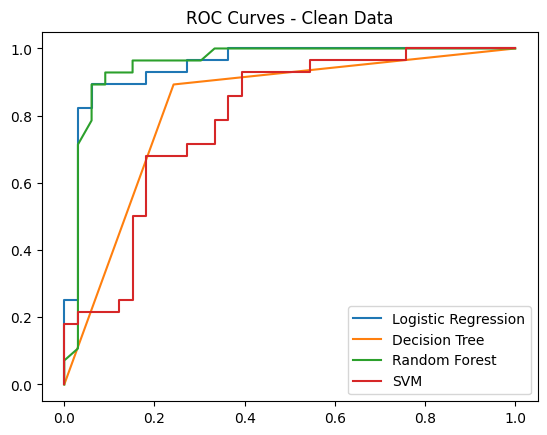

In [14]:
for name, model in models.items():
    model.fit(Xc_train, yc_train)
    y_prob = model.predict_proba(Xc_test)[:,1]

    fpr, tpr, _ = roc_curve(yc_test, y_prob)

    plt.plot(fpr, tpr, label=name)

plt.legend()
plt.title("ROC Curves - Clean Data")
plt.show()

In [15]:
import joblib

joblib.dump(models["Random Forest"], "../models/rf_model.pkl")
joblib.dump(models["Logistic Regression"], "../models/lr_model.pkl")
joblib.dump(models["SVM"], "../models/svm_model.pkl")
joblib.dump(models["Decision Tree"], "../models/dt_model.pkl")

best_model = models["Random Forest"]
joblib.dump(best_model, "../models/best_model.pkl")

['../models/best_model.pkl']

## Insights

1. Random Forest achieved the highest overall accuracy and AUC on the clean dataset.

2. Logistic Regression performed consistently across all datasets,
indicating a strong linear relationship.

3. PCA improved SVM performance significantly.

4. Feature Selection reduced dimensionality while maintaining comparable performance.

5. Decision Tree showed lower performance and signs of overfitting.